# 05 — Composite limits, no atmosphere

The counterpart to [`01`](01_limit_contour.ipynb) / [`04`](04_mode_comparison.ipynb),
with overburden attenuation **switched off**: the DM velocity distribution is the
bare standard halo model for every $(m_{\rm DM}, \alpha_n)$ (no attenuation ODE),
so there is **no atmospheric ceiling** — exclusion runs up to $\alpha_n = 1$. This
isolates what the atmosphere costs (compare the top edge here with the ceiling in
notebook 04).

**Composite** = the three sensor modes combined: a point is excluded if *any*
mode excludes it (element-wise max of the extremeness). Shown per mediator range,
at the same fiducials otherwise — $q_\text{min}$ = 0.1 TeV/$c$, per-mode
efficiency, candidates `data_mode{n}.txt`, $T$ = 469.7 h.

Caches: `computation_cache_noatm/mode{n}/scan7_{tag}.npz`
(from `scan_grid.py --no-atmosphere`).

In [1]:
%matplotlib inline
from pathlib import Path
import os as _os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)
def save_figure(fig, name, **kw):
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)

MODES = (1, 2, 3)
CACHE = Path("computation_cache_noatm")
CONF = 0.95
M_PLANCK = 1.22e19
G_PER_GEV = 1.78266192e-24   # 1 GeV/c^2 in grams

RANGES = ["massless", "2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
LABEL = {"massless": "massless", "2m": "2 m", "2cm": "2 cm", "2mm": "2 mm",
         "200um": "200 \u00b5m", "20um": "20 \u00b5m", "10um": "10 \u00b5m", "2um": "2 \u00b5m"}
STYLE = {"massless": "solid", "2m": (0, (5, 1)), "2cm": (0, (1, 1)),
         "2mm": (0, (3, 5, 1, 5)), "200um": (0, (5, 5)), "20um": (0, (3, 1, 1, 1)),
         "10um": (0, (1, 10)), "2um": (0, (3, 5, 1, 5, 1, 5))}
# colour ramp over ranges (long range dark -> short range light), viridis
RCOLOR = {t: plt.cm.viridis(x) for t, x in zip(RANGES, np.linspace(0.05, 0.85, len(RANGES)))}

def composite(tag):
    """(ms, alphas, max-over-modes extremeness) for one range, or None."""
    ext, ms, al = None, None, None
    for n in MODES:
        f = CACHE / f"mode{n}" / f"scan7_{tag}.npz"
        if not f.exists():
            continue
        d = np.load(f)
        ms, al = d["ms"], d["alphas_n"]
        ext = d["extremeness"] if ext is None else np.maximum(ext, d["extremeness"])
    return None if ext is None else (ms, al, ext)

## Status

In [2]:
for tag in RANGES:
    present = [n for n in MODES if (CACHE / f"mode{n}" / f"scan7_{tag}.npz").exists()]
    c = composite(tag)
    frac = f"{(c[2] >= CONF).mean():.3f}" if c else "  ...  "
    print(f"{tag:>9} | modes {present or '-'} | composite excluded {frac}")

 massless | modes [1, 2, 3] | composite excluded 0.621
       2m | modes [1, 2, 3] | composite excluded 0.546
      2cm | modes [1, 2, 3] | composite excluded 0.416
      2mm | modes [1, 2, 3] | composite excluded 0.323
    200um | modes [1, 2, 3] | composite excluded 0.215
     20um | modes [1, 2, 3] | composite excluded 0.070
     10um | modes [1, 2, 3] | composite excluded 0.025
      2um | modes [1, 2, 3] | composite excluded 0.000


## Composite (3-mode) exclusion — no atmosphere

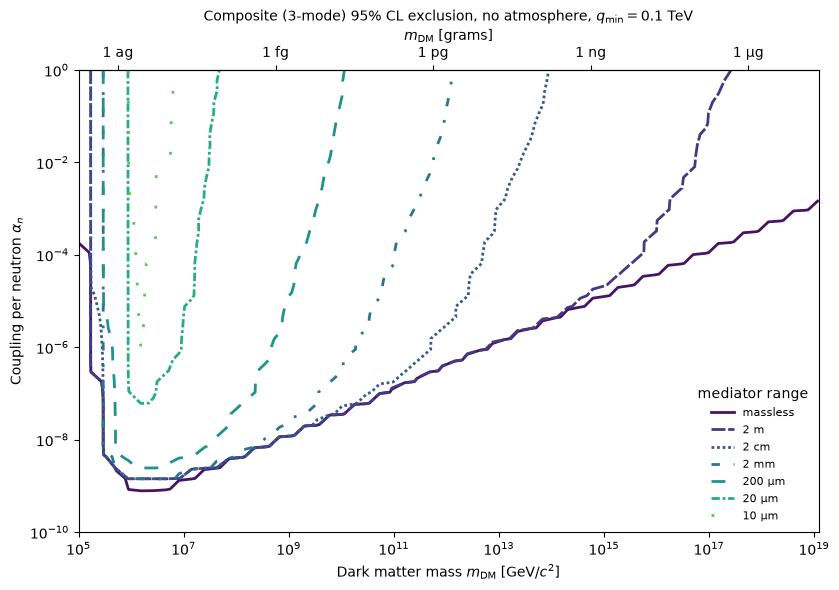

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 6))
xmin = M_PLANCK
drawn = []
for tag in RANGES:
    c = composite(tag)
    if c is None:
        continue
    ms, al, ext = c
    if not (ext >= CONF).any():
        continue
    xmin = min(xmin, ms.min())
    drawn.append(tag)
    ax.contour(ms, al, ext, levels=[CONF], colors=[RCOLOR[tag]],
               linestyles=[STYLE[tag]], linewidths=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(xmin, M_PLANCK); ax.set_ylim(1e-10, 1.0)
ax.set_xlabel(r"Dark matter mass $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per neutron $\alpha_n$")
sec = ax.secondary_xaxis("top",
                         functions=(lambda x: x*G_PER_GEV, lambda g: g/G_PER_GEV))
sec.set_xlabel(r"$m_{\rm DM}$ [grams]")
_gt = [1e-18, 1e-15, 1e-12, 1e-9, 1e-6]; _gl = ["1 ag", "1 fg", "1 pg", "1 ng", "1 \u00b5g"]
_keep = [(t, l) for t, l in zip(_gt, _gl) if xmin*G_PER_GEV <= t <= M_PLANCK*G_PER_GEV]
sec.set_xticks([t for t, _ in _keep]); sec.set_xticklabels([l for _, l in _keep])
sec.xaxis.set_minor_locator(plt.NullLocator())
ax.set_title("Composite (3-mode) 95% CL exclusion, no atmosphere, $q_{\\rm min}=0.1$ TeV",
             fontsize=10)
handles = [Line2D([], [], color=RCOLOR[t], lw=2, linestyle=STYLE[t], label=LABEL[t])
           for t in RANGES if t in drawn]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=8,
          title="mediator range")
fig.tight_layout(); save_figure(fig, "05_composite_noatm"); plt.show()